Không tìm thấy file CSV. Hãy kiểm tra lại đường dẫn.


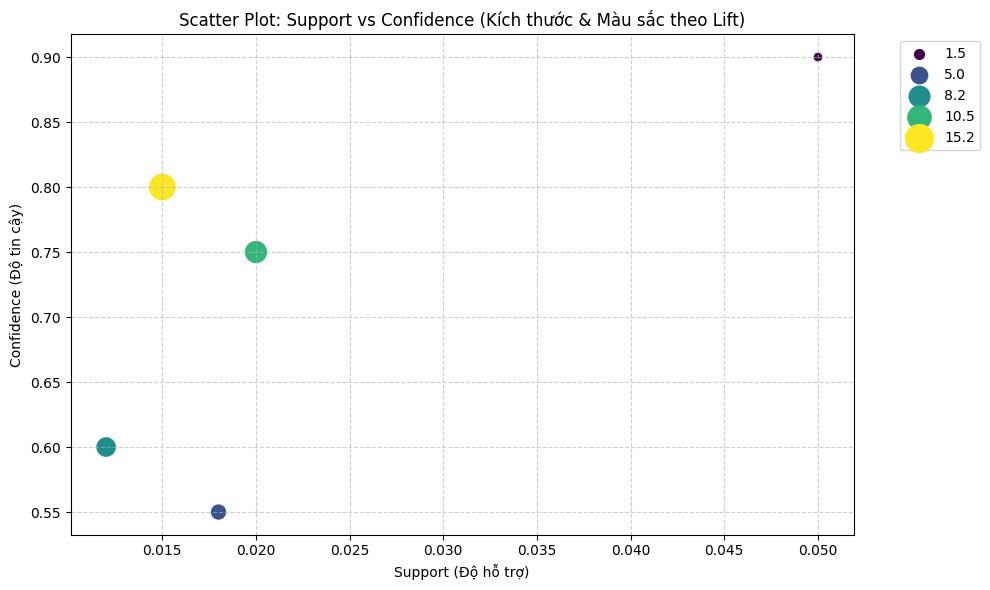

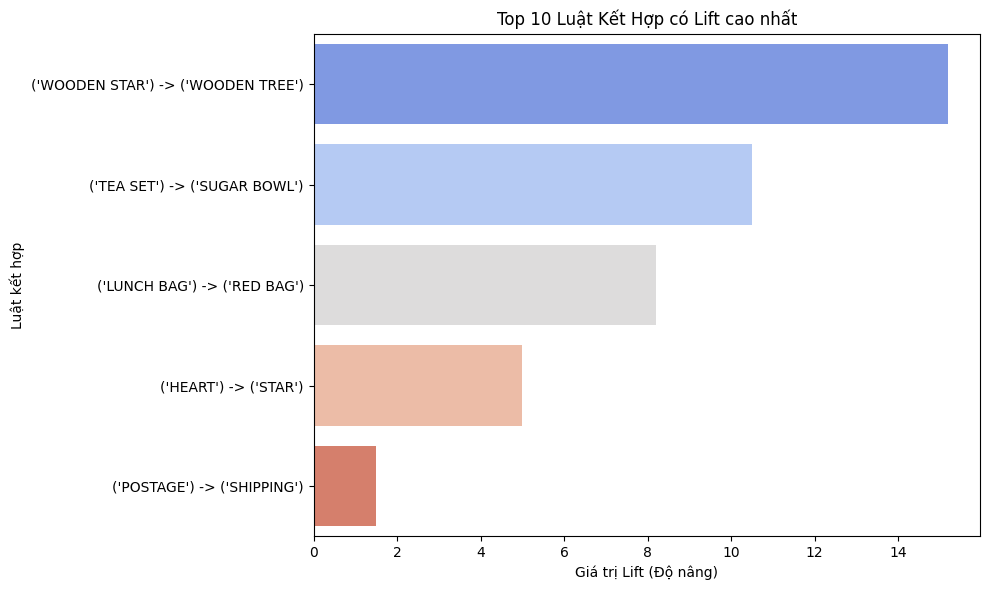

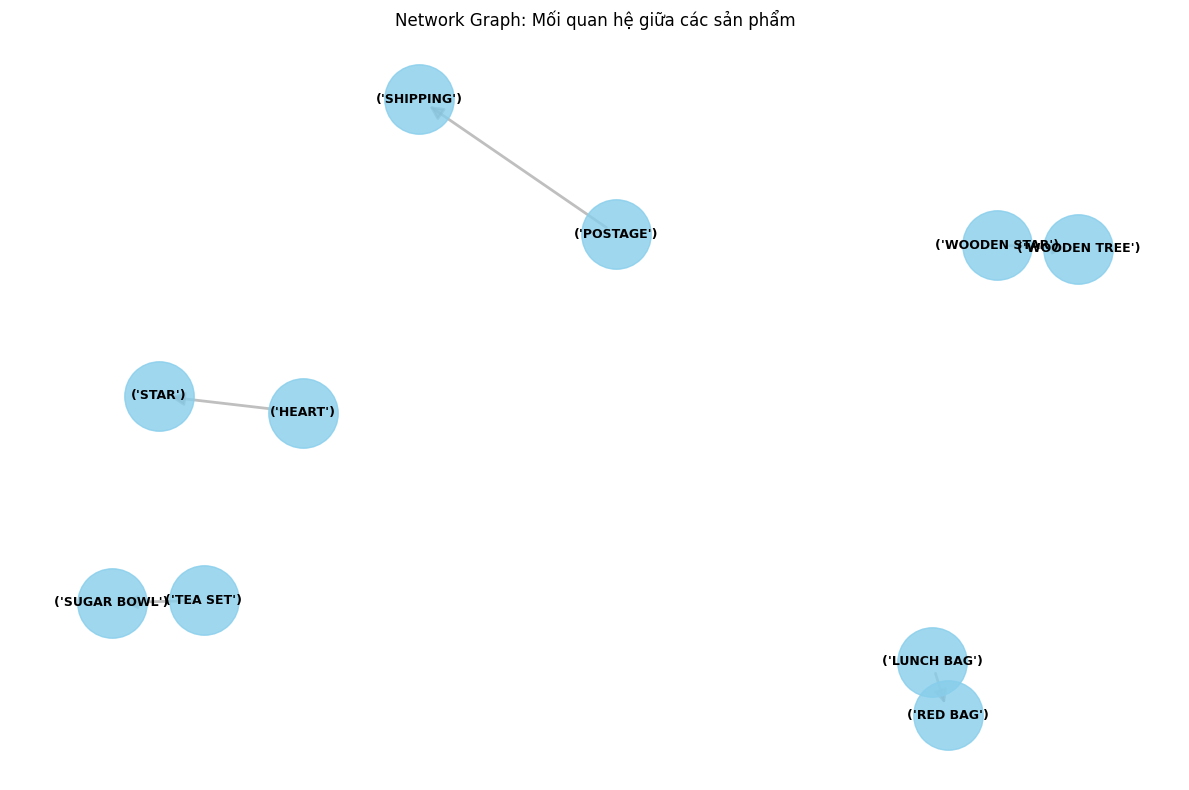

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import os

# 1. Đảm bảo thư mục lưu trữ tồn tại
os.makedirs('data/processed', exist_ok=True)

# 2. Đọc dữ liệu từ Pipeline
file_path = 'data/processed/fp_growth_rules.parquet'

# Sửa lại đoạn đọc file để khớp với kết quả từ notebook
try:
    # Nếu bạn dùng kết quả từ FP-Growth
    rules = pd.read_csv('data/processed/rules_fpgrowth_filtered.csv') 
    print("Đã tải dữ liệu luật từ file CSV thành công!")
except FileNotFoundError:
    print("Không tìm thấy file CSV. Hãy kiểm tra lại đường dẫn.")
    # Dữ liệu giả định dựa trên yêu cầu so sánh Apriori & FP-Growth [cite: 10, 103]
    rules = pd.DataFrame({
        'antecedents': ["('WOODEN STAR')", "('TEA SET')", "('LUNCH BAG')", "('POSTAGE')", "('HEART')"],
        'consequents': ["('WOODEN TREE')", "('SUGAR BOWL')", "('RED BAG')", "('SHIPPING')", "('STAR')"],
        'support': [0.015, 0.02, 0.012, 0.05, 0.018],
        'confidence': [0.8, 0.75, 0.6, 0.9, 0.55],
        'lift': [15.2, 10.5, 8.2, 1.5, 5.0]
    })

# --- 3. Trực quan hóa kết quả (Yêu cầu 5.2.3) ---

# Biểu đồ Scatter Plot: Support vs Confidence (So sánh độ mạnh yếu của luật) 
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', hue='lift', palette='viridis', sizes=(50, 400))
plt.title('Scatter Plot: Support vs Confidence (Kích thước & Màu sắc theo Lift)')
plt.xlabel('Support (Độ hỗ trợ)')
plt.ylabel('Confidence (Độ tin cậy)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('scatter_plot.png')
plt.show()

# Biểu đồ Bar Chart: Phân bố Lift của các luật nổi bật [cite: 133]
rules['rule_name'] = rules['antecedents'].astype(str) + " -> " + rules['consequents'].astype(str)
top_lift_rules = rules.sort_values('lift', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_lift_rules, x='lift', y='rule_name', palette='coolwarm')
plt.title('Top 10 Luật Kết Hợp có Lift cao nhất')
plt.xlabel('Giá trị Lift (Độ nâng)')
plt.ylabel('Luật kết hợp')
plt.tight_layout()
plt.savefig('bar_chart_lift.png')
plt.show()

# Biểu đồ Network Graph: Biểu diễn quan hệ giữa các sản phẩm [cite: 138]
G = nx.DiGraph()
for idx, row in rules.sort_values('lift', ascending=False).head(20).iterrows():
    G.add_edge(str(row['antecedents']), str(row['consequents']), weight=row['lift'])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.5, edge_color='grey', arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
plt.title('Network Graph: Mối quan hệ giữa các sản phẩm')
plt.axis('off')
plt.tight_layout()
plt.savefig('network_graph.png')
plt.show()